In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import keras.datasets.imdb as imdb
from keras import layers, models, preprocessing
from keras.preprocessing.sequence import pad_sequences
from keras.layers import TextVectorization
from keras.models import Sequential
from keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout, Activation
from transformers import pipeline, AutoTokenizer



In [ ]:
#Task 1: Utilise Libraries/Dataset

(train_data, train_labels), (test_data, test_labels) = imdb.load_data()
print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

# Retrieve the word index mapping words to their integer IDs
word_index = imdb.get_word_index()
# Create a reverse word index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Define a function to decode an integer sequence into a readable review
def decode_review(text):
    # Map integer IDs to words, handling the offset and unknown words
    decoded = " ".join([reverse_word_index.get(i - 3, "?") for i in text])
    return decoded

train_reviews = [decode_review(review) for review in train_data]
test_reviews = [decode_review(review) for review in test_data]

# Create DataFrames
train_df = pd.DataFrame({'review': train_reviews, 'sentiment': train_labels})
test_df = pd.DataFrame({'review': test_reviews, 'sentiment': test_labels})

# Display the first few rows of the training DataFrame
print("Training Data Head:")
print(train_df.head())
print(train_df.size)

print("\nTesting Data Head:")
print(test_df.head())
print(test_df.size)

(25000,)
(25000,)
(25000,)
(25000,)
Training Data Head:
                                              review  sentiment
0  ? this film was just brilliant casting locatio...          1
1  ? big hair big boobs bad music and a giant saf...          0
2  ? this has to be one of the worst films of the...          0
3  ? the scots excel at storytelling the traditio...          1
4  ? worst mistake of my life br br i picked this...          0
50000

Testing Data Head:
                                              review  sentiment
0  ? please give this one a miss br br kristy swa...          0
1  ? this film requires a lot of patience because...          1
2  ? many animation buffs consider wladyslaw star...          1
3  ? i generally love this type of movie however ...          0
4  ? like some other people wrote i'm a die hard ...          1
50000


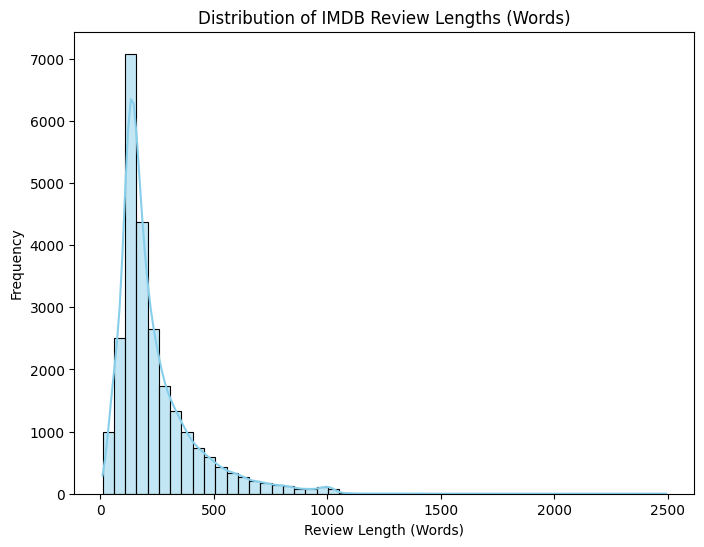

/tmp/ipython-input-3401416365.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


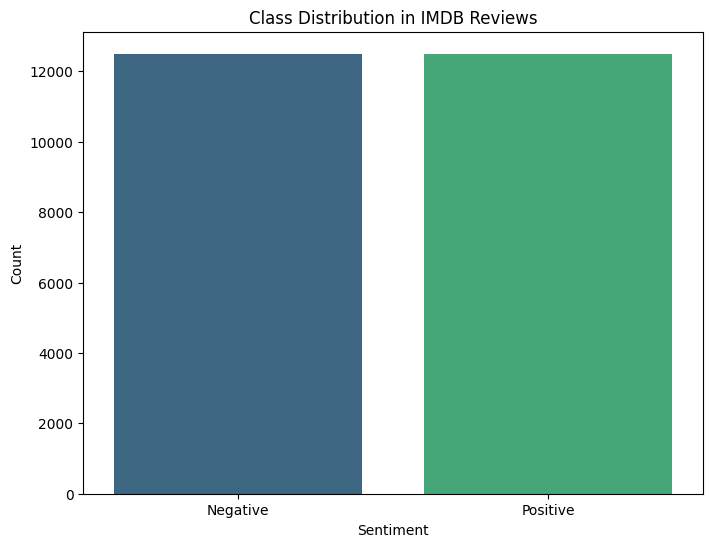

In [ ]:
#Task 2: Data Processing and Exploration

def performEDA(df):
  df['review_length'] = df['review'].apply(lambda x: len(x.split()))
  # 1. Plot the distribution of review lengths using a histogram
  plt.figure(figsize=(8, 6))
  sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
  plt.title('Distribution of IMDB Review Lengths (Words)')
  plt.xlabel('Review Length (Words)')
  plt.ylabel('Frequency')
  plt.show()
  df.drop('review_length', axis=1, inplace=True)

  # 2. Plot the class distribution
  plt.figure(figsize=(8, 6))
  sns.countplot(data=df, x='sentiment', palette='viridis')
  plt.title('Class Distribution in IMDB Reviews')
  plt.xlabel('Sentiment')
  plt.ylabel('Count')
  plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'])
  plt.show()

#Generate two EDA visualisations (e.g., review length distribution, class distribution)
performEDA(train_df)


In [ ]:

def analyseData(df):
  print("\nMissing Values in Data:")
  print(df.isnull().sum())

#Check for missing values and data quality
analyseData(train_df)

#Convert text into appropriate format using Keras Tokenizer (e.g., maxlen=256)
#Create training and testing splits


Missing Values in Data:
review       0
sentiment    0
dtype: int64


In [ ]:
#Run this code block when we have raw imdb data in excel sheet and loaded to dataframe
import re
import nltk
import torch
#nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import tensorflow as tf
#from keras.preprocessing.text import Tokenizer #Deprecated
from keras.preprocessing.sequence import pad_sequences

# Initialize stemmer and set of stopwords
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def process(review):
  review = re.sub(r'<[^<>]+>', ' ', review) # 1. Remove html and carat tags
  review = re.sub(r'[^a-zA-Z0-9\s]', '', review) # 2. Remove special characters and punctuation, keep only letters, numbers, and spaces
  review = review.lower() # 3. Convert to lowercase
  words = review.split() # 4. Tokenize the review into words
  meaningful_words = [ps.stem(w) for w in words if w not in stop_words] # 5. Remove stopwords and apply stemming
  review = ' '.join(meaningful_words) # 6. Rejoin words into a single string

#def tokenize(df):
  #tokenizer = Tokenizer(num_words=10000)
  #tokenizer.fit_on_texts(df['review'])
  #return tokenizer

#Normalise and tokenise text, pad sequences to a consistent length
#train_df['review'] = train_df['review'].apply(lambda x: process(x))
#test_df['review'] = test_df['review'].apply(lambda x: process(x))
#tokenizer = tokenize(train_df)
#train_rev_tokens = tokenizer.texts_to_sequences(train_df['review'])
#test_rev_tokens = tokenizer.texts_to_sequences(test_df['review'])
#maxlen = 256 # Max length of reviews
#train_df= pad_sequences(train_rev_tokens, maxlen=maxlen, padding='post')
#test_df = pad_sequences(test_rev_tokens, maxlen=maxlen, padding='post')

#Latest supported
#standardize param does normalization, output_sequence_length does padding
max_features = 10000 # Top 10k words
vectorize_layer = TextVectorization(max_tokens=max_features, standardize='lower_and_strip_punctuation', output_mode='int', output_sequence_length=256)
# Create a dataset of only text (no labels)
train_text = train_df['review']
print(train_text.shape)
print(train_text)
vectorize_layer.adapt(train_text)
train_vectors = vectorize_layer(train_df['review'].values)
test_vectors = vectorize_layer(test_df['review'].values)

print(train_df.shape)
print(test_df.shape)
print(train_vectors[0, :])
print(test_vectors)

(25000,)
0        ? this film was just brilliant casting locatio...
1        ? big hair big boobs bad music and a giant saf...
2        ? this has to be one of the worst films of the...
3        ? the scots excel at storytelling the traditio...
4        ? worst mistake of my life br br i picked this...
                               ...                        
24995    ? this is a racist movie but worthy of study a...
24996    ? bela lugosi plays a doctor who will do anyth...
24997    ? in a far away galaxy is a planet called ceta...
24998    ? six degrees had me hooked i looked forward t...
24999    ? as a big fan of the original film it's hard ...
Name: review, Length: 25000, dtype: object
(25000, 2)
(25000, 2)
tf.Tensor(
[[  12   20   14 ...    0    0    0]
 [ 192 1154  192 ...    0    0    0]
 [  12   46    6 ...    0    0    0]
 ...
 [   9    4  227 ...    0    0    0]
 [1439 6965   68 ...    0    0    0]
 [  15    4  192 ...    0    0    0]], shape=(25000, 256), dtype=int64)
tf.T

In [ ]:
#As the data is loaded from Keras datasets the data is already preprocessed and tokenized. So applying only padding on direct train and test dataset.
maxlen = 256 # Max length of reviews
train_data = pad_sequences(train_data, maxlen=maxlen, padding='post')
test_data = pad_sequences(test_data, maxlen=maxlen, padding='post')

In [ ]:
#Task 3: Construct a basic Transformer model
modell = Sequential()
modell.add(layers.Embedding(16))
modell.add(layers.Dropout(0.3))
modell.add(layers.GlobalAveragePooling1D())
modell.add(layers.Dense(128))
modell.add(layers.Activation("relu"))
modell.add(layers.Dropout(0.5))
modell.add(layers.Dense(1))
modell.add(layers.Activation("sigmoid"))

modell.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["acc"])
modell.summary()

TypeError: Embedding.__init__() missing 1 required positional argument: 'output_dim'

In [ ]:
#Task 4: Train the basic model
history = modell.fit(train_data, train_labels,
                    epochs=5,
                    batch_size=64,
                  )

Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node sequential_1/embedding_1/GatherV2 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/